🚀 算力怪兽：深水区万阶绝对对齐 (1D vs GUE vs 线性拟合 极简消融版)
[*] 正在加载黎曼零点...
[*] 成功加载靶向零点，总数: 10000，最高能级: 9877.78
[*] 正在启动 Jupyter 线程池 (任务数: 2)... 预计需要 1~2 小时，请耐心等待！
[M-GUE: Gaussian Unitary Ensemble (Global Scaled)] GUE 随机矩阵生成完成，耗时: 77.7s, 正在求解厄米特征值...
[M-GUE: Gaussian Unitary Ensemble (Global Scaled)] 提取完毕! 对齐: 10000 阶 | 全局缩放 Scale=45.5610 | MSE=255455.92
[M1: 1D Thermodynamic Cooling (k1=13.431)] 稠密积分完成，耗时: 4657.1s, 正在转入暴力特征值求解...
[M1: 1D Thermodynamic Cooling (k1=13.431)] 提取完毕! 对齐: 10000 阶 | 全局缩放 Scale=4322.9499 | MSE=70881.70

[+] 宏观万阶消融大图(1D极简版)已保存为 macroscopic_10000_ablation_1d_vs_gue.png！


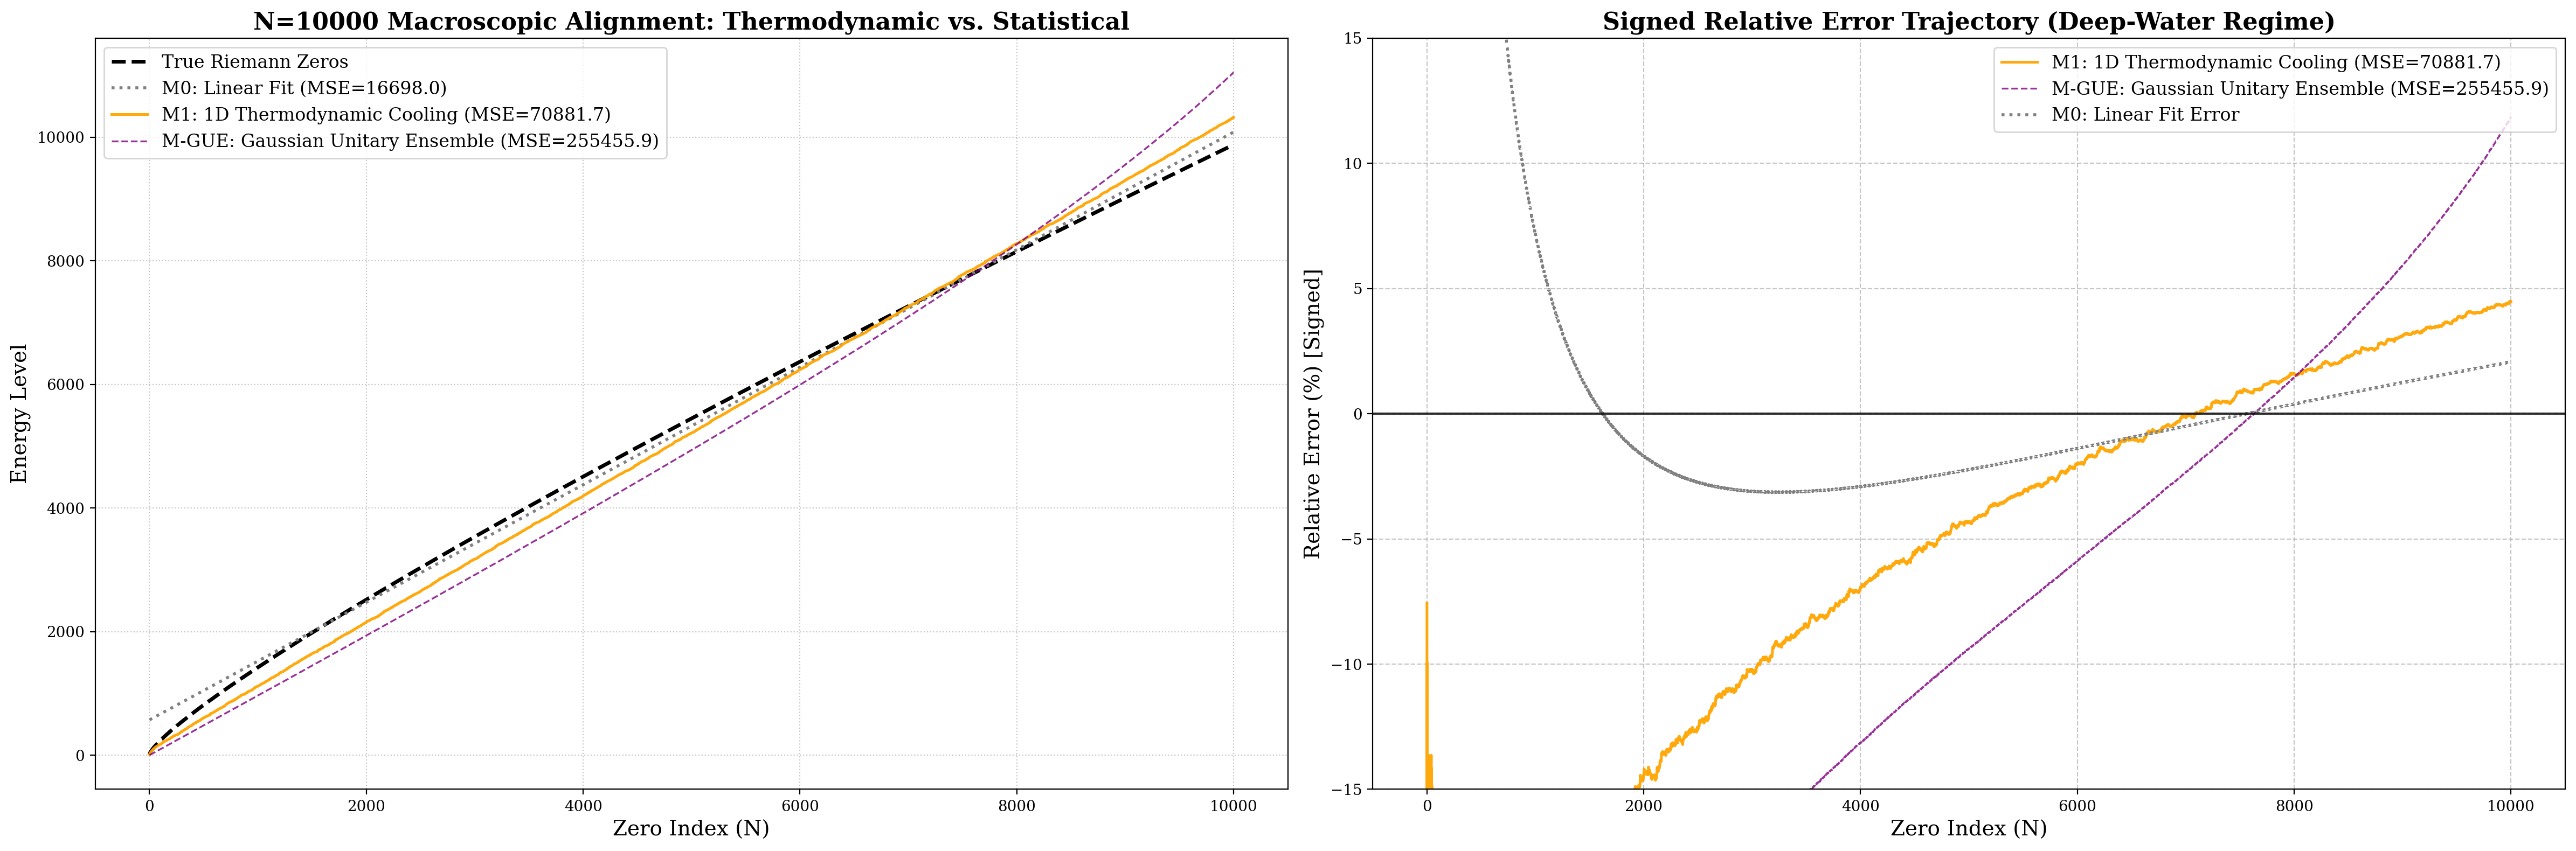

In [1]:
import os
# 🔥 榨干多核性能，必须在 numpy 导入前设置
os.environ["OMP_NUM_THREADS"] = "12"
os.environ["MKL_NUM_THREADS"] = "12"
os.environ["OPENBLAS_NUM_THREADS"] = "12"
os.environ["NUMBA_NUM_THREADS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
from numba import njit
import time
import concurrent.futures

print("="*95)
print("🚀 算力怪兽：深水区万阶绝对对齐 (1D vs GUE vs 线性拟合 极简消融版)")
print("="*95)

# ================= 1. 准备真实的黎曼零点 (10000个) =================
N_compare = 10000

print("[*] 正在加载黎曼零点...")
try:
    # 强烈建议直接读取你算好的 npy 文件，用 mpmath 现场算 1 万个点太慢了
    true_zeros = np.load("riemann_10k_true.npy")[:N_compare]
    print(f"[*] 成功加载靶向零点，总数: {len(true_zeros)}，最高能级: {true_zeros[-1]:.2f}")
except FileNotFoundError:
    print("[-] 未找到 riemann_10k_true.npy，正在调用 mpmath 现场计算 (可能需要数分钟)...")
    import mpmath
    mpmath.mp.dps = 25
    true_zeros = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_compare + 1)])

u_c_target = 1.543689
steps_global = 50_000_000_000  # 500 亿步绝热冷却
offset_global = 100000.0
n_bins_global = 50000          # 5w网格分辨率！

# ================= 2. 内存隔离的极限动力学内核 (float32 原位操作) =================
@njit(fastmath=True, nogil=True)
def kernel_1d(u_temp, k1, steps, n_bins, offset):
    counts = np.zeros((n_bins, n_bins), dtype=np.float32)
    x = 0.5
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    
    warmup_steps = 2000000 
    for i in range(warmup_steps):
        L_i = np.log(i + offset)
        u_dyn = u_temp + k1 / (L_i**2)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
            
    for i in range(warmup_steps, steps + warmup_steps):
        L_i = np.log(i + offset)
        u_dyn = u_temp + k1 / (L_i**2)
        x = 1.0 - u_dyn * x**2
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        if 0 <= current_bin < n_bins and 0 <= last_bin < n_bins: 
            counts[last_bin, current_bin] += 1.0
        last_bin = current_bin

    # C级别原位归一化
    for i in range(n_bins):
        row_sum = np.float32(0.0)
        for j in range(n_bins):
            row_sum += counts[i, j]
        if row_sum > 0.0:
            inv_sum = np.float32(1.0) / row_sum
            for j in range(n_bins):
                counts[i, j] *= inv_sum
        else:
            counts[i, i] = np.float32(1.0)
    return counts

# ================= 3. 线程 Worker =================
def worker_task(task_info):
    name, model_type, params = task_info
    t0 = time.time()
    L_end = np.log(steps_global + offset_global)
    
    if model_type == '1D':
        k1 = params[0]
        u_temp = u_c_target - k1 / (L_end**2)
        P = kernel_1d(u_temp, k1, steps_global, n_bins_global, offset_global)
        print(f"[{name}] 稠密积分完成，耗时: {time.time()-t0:.1f}s, 正在转入暴力特征值求解...")
        vals = scipy.linalg.eigvals(P)
        valid_mask = (vals.imag > 1e-5)
        sim_pos = np.unwrap(np.sort(np.angle(vals[valid_mask])))
        
    elif model_type == 'RMT':
        # 💡 RMT: 生成 22000 维的 GUE 以确保正半轴有 >10000 个特征值
        N_dim = 22000 
        np.random.seed(42)
        A = np.random.randn(N_dim, N_dim) + 1j * np.random.randn(N_dim, N_dim)
        H_gue = (A + A.conj().T) / 2.0 
        print(f"[{name}] GUE 随机矩阵生成完成，耗时: {time.time()-t0:.1f}s, 正在求解厄米特征值...")
        vals = scipy.linalg.eigvalsh(H_gue)
        sim_pos = np.sort(vals[vals > 0])
        sim_pos = sim_pos - sim_pos[0] + 0.01 
        
    N_actual = min(len(sim_pos), len(true_zeros))
    sim_pos = sim_pos[:N_actual]
    tz_pos = true_zeros[:N_actual]
    
    # 🌟 统一使用全局最小二乘缩放 (Global Scaling)
    scale = np.dot(sim_pos, tz_pos) / np.dot(sim_pos, sim_pos)
    calib = scale * sim_pos
        
    # 🔥 保留正负漂移趋势！
    rel_err_signed = (calib - tz_pos) / tz_pos * 100
    mse = np.mean((calib - tz_pos)**2)
    
    print(f"[{name}] 提取完毕! 对齐: {N_actual} 阶 | 全局缩放 Scale={scale:.4f} | MSE={mse:.2f}")
    
    pad_width = N_compare - N_actual
    full_calib = np.pad(calib, (0, pad_width), constant_values=np.nan)
    full_err_signed = np.pad(rel_err_signed, (0, pad_width), constant_values=np.nan)
    return name, full_calib, full_err_signed, mse

# ================= 4. 主程序：并发联合作战 =================
if __name__ == "__main__":
    
    # -- 0. 线性拟合基线 (10000阶) --
    n_indices = np.arange(1, N_compare + 1)
    slope, intercept = np.polyfit(n_indices, true_zeros, 1)
    calib_lin = slope * n_indices + intercept
    err_lin_signed = (calib_lin - true_zeros) / true_zeros * 100
    mse_lin = np.mean((calib_lin - true_zeros)**2)

    # -- 设置 1D 和 GUE(RMT) 任务 --
    tasks = [
        # 使用新鲜出炉的万阶最强 k1
        ("M1: 1D Thermodynamic Cooling (k1=13.431)", '1D', [13.431184968488722]),
        ("M-GUE: Gaussian Unitary Ensemble (Global Scaled)", 'RMT', []) 
    ]
    
    print(f"[*] 正在启动 Jupyter 线程池 (任务数: {len(tasks)})... 预计需要 1~2 小时，请耐心等待！")
    results = []
    # 开启 2 个线程即可
    with concurrent.futures.ThreadPoolExecutor(max_workers=2) as executor:
        results = list(executor.map(worker_task, tasks))
        
    # ================= 5. 封神绘图 =================
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    fig, axes = plt.subplots(1, 2, figsize=(24, 8), dpi=200) 
    
    # --- 左图：绝对预测值 ---
    axes[0].plot(true_zeros, 'k--', linewidth=2.5, label='True Riemann Zeros')
    axes[0].plot(calib_lin, color='gray', linestyle=':', linewidth=2, label=f'M0: Linear Fit (MSE={mse_lin:.1f})')
    
    styles = [
        {'color': 'orange', 'linestyle': '-', 'linewidth': 1.8, 'alpha': 0.95},   # 1D
        {'color': 'purple', 'linestyle': '--', 'linewidth': 1.2, 'alpha': 0.8}    # GUE
    ]
    
    for i, res in enumerate(results):
        name, calib, err_signed, mse = res
        style = styles[i]
        short_name = name.split('(')[0].strip()
        label_str = f"{short_name} (MSE={mse:.1f})"
        
        axes[0].plot(calib, color=style['color'], linestyle=style['linestyle'], linewidth=style['linewidth'], alpha=style['alpha'], label=label_str)
        axes[1].plot(np.arange(1, N_compare + 1), err_signed, color=style['color'], linestyle=style['linestyle'], linewidth=style['linewidth'], alpha=style['alpha'], label=label_str)

    # 在右图加上线性拟合的巨大发散趋势
    axes[1].plot(np.arange(1, N_compare + 1), err_lin_signed, color='gray', linestyle=':', linewidth=2, label=f'M0: Linear Fit Error')

    axes[0].set_title("N=10000 Macroscopic Alignment: Thermodynamic vs. Statistical", fontsize=16, fontweight='bold')
    axes[0].set_xlabel("Zero Index (N)", fontsize=14)
    axes[0].set_ylabel("Energy Level", fontsize=14)
    axes[0].legend(loc='upper left', fontsize=12)
    axes[0].grid(True, linestyle=':', alpha=0.7)

    # --- 右图特殊处理 ---
    axes[1].axhline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.8) 
    axes[1].set_title("Signed Relative Error Trajectory (Deep-Water Regime)", fontsize=16, fontweight='bold')
    axes[1].set_xlabel("Zero Index (N)", fontsize=14)
    axes[1].set_ylabel("Relative Error (%) [Signed]", fontsize=14)
    axes[1].legend(loc='upper right', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # 获取 1D 模型的最大相对误差，作为对称边界，彻底暴露 GUE 的结构性崩溃
    max_1d_err = np.nanmax(np.abs(results[0][2]))
    # 动态限制 Y 轴：给 1D 留点呼吸空间，同时让 GUE 和 Linear 的线夸张地飞出屏幕外
    y_limit = min(max_1d_err * 2.0, 15.0) 
    axes[1].set_ylim(-y_limit, y_limit) 

    plt.tight_layout()
    plt.savefig("macroscopic_10000_ablation_1d_vs_gue.png")
    print("\n[+] 宏观万阶消融大图(1D极简版)已保存为 macroscopic_10000_ablation_1d_vs_gue.png！")
    plt.show()